# 01 — Banking77 Data Exploration (EDA)

**Project**: Customer Support Call Analyzer  
**Role**: Developer 1 — AI / NLP Engineer  
**Dataset**: Banking77 — 77 fine-grained intent classes for online banking queries

---

### Goals
- Confirm data shape and integrity
- Understand class distribution (imbalance analysis)
- Analyse text length statistics
- Surface any data quality issues before training

In [2]:
# ── Standard library & third-party imports ──────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Nice plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Imports OK')

Imports OK


## 1. Load Dataset

In [3]:
TRAIN_PATH = '../data/raw/banking77-train.csv'
TEST_PATH  = '../data/raw/banking77-test.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train_df.shape}')   # Expected: (9993, 3)
print(f'Test shape  : {test_df.shape}')    # Expected: (3076, 3)
print()
train_df.head()

Train shape : (9993, 3)
Test shape  : (3076, 3)



,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


## 2. Schema & Sample

In [4]:
print('=== TRAIN DTYPES ===')
print(train_df.dtypes)
print()
print('=== SAMPLE ROWS ===')
train_df[['text', 'label_text']].sample(5, random_state=42)

=== TRAIN DTYPES ===
text          object
label          int64
label_text    object
dtype: object

=== SAMPLE ROWS ===


,text,label_text
3123,What are the limits to where my card will be a...,card_acceptance
1441,I would like to change currency,exchange_via_app
6282,I have lost my credit card in the ATM!,card_swallowed
39,My card still hasn't been delivered,card_arrival
4094,Can you deliver the PIN separately?,get_physical_card


## 3. Missing Value Check

In [5]:
print('=== TRAIN NULLS ===')
print(train_df.isnull().sum())
print()
print('=== TEST NULLS ===')
print(test_df.isnull().sum())

assert train_df.isnull().sum().sum() == 0, 'Nulls found in train!'
assert test_df.isnull().sum().sum()  == 0, 'Nulls found in test!'
print()
print('✅ No missing values in either split.')

=== TRAIN NULLS ===
text          0
label         0
label_text    0
dtype: int64

=== TEST NULLS ===
text          0
label         0
label_text    0
dtype: int64

✅ No missing values in either split.


## 4. Intent / Label Verification

In [6]:
n_train_labels = train_df['label_text'].nunique()
n_test_labels  = test_df['label_text'].nunique()

print(f'Unique intents in TRAIN : {n_train_labels}')  # Expected: 77
print(f'Unique intents in TEST  : {n_test_labels}')   # Expected: 77

# Verify every test label appears in train
unseen = set(test_df['label_text'].unique()) - set(train_df['label_text'].unique())
print(f'Test labels NOT in train: {unseen if unseen else "None — all aligned ✅"}')

Unique intents in TRAIN : 77
Unique intents in TEST  : 77
Test labels NOT in train: None — all aligned ✅


## 5. Class Distribution

Min samples per class : 35
Max samples per class : 187
Mean samples per class: 129.8
Std  samples per class: 33.0



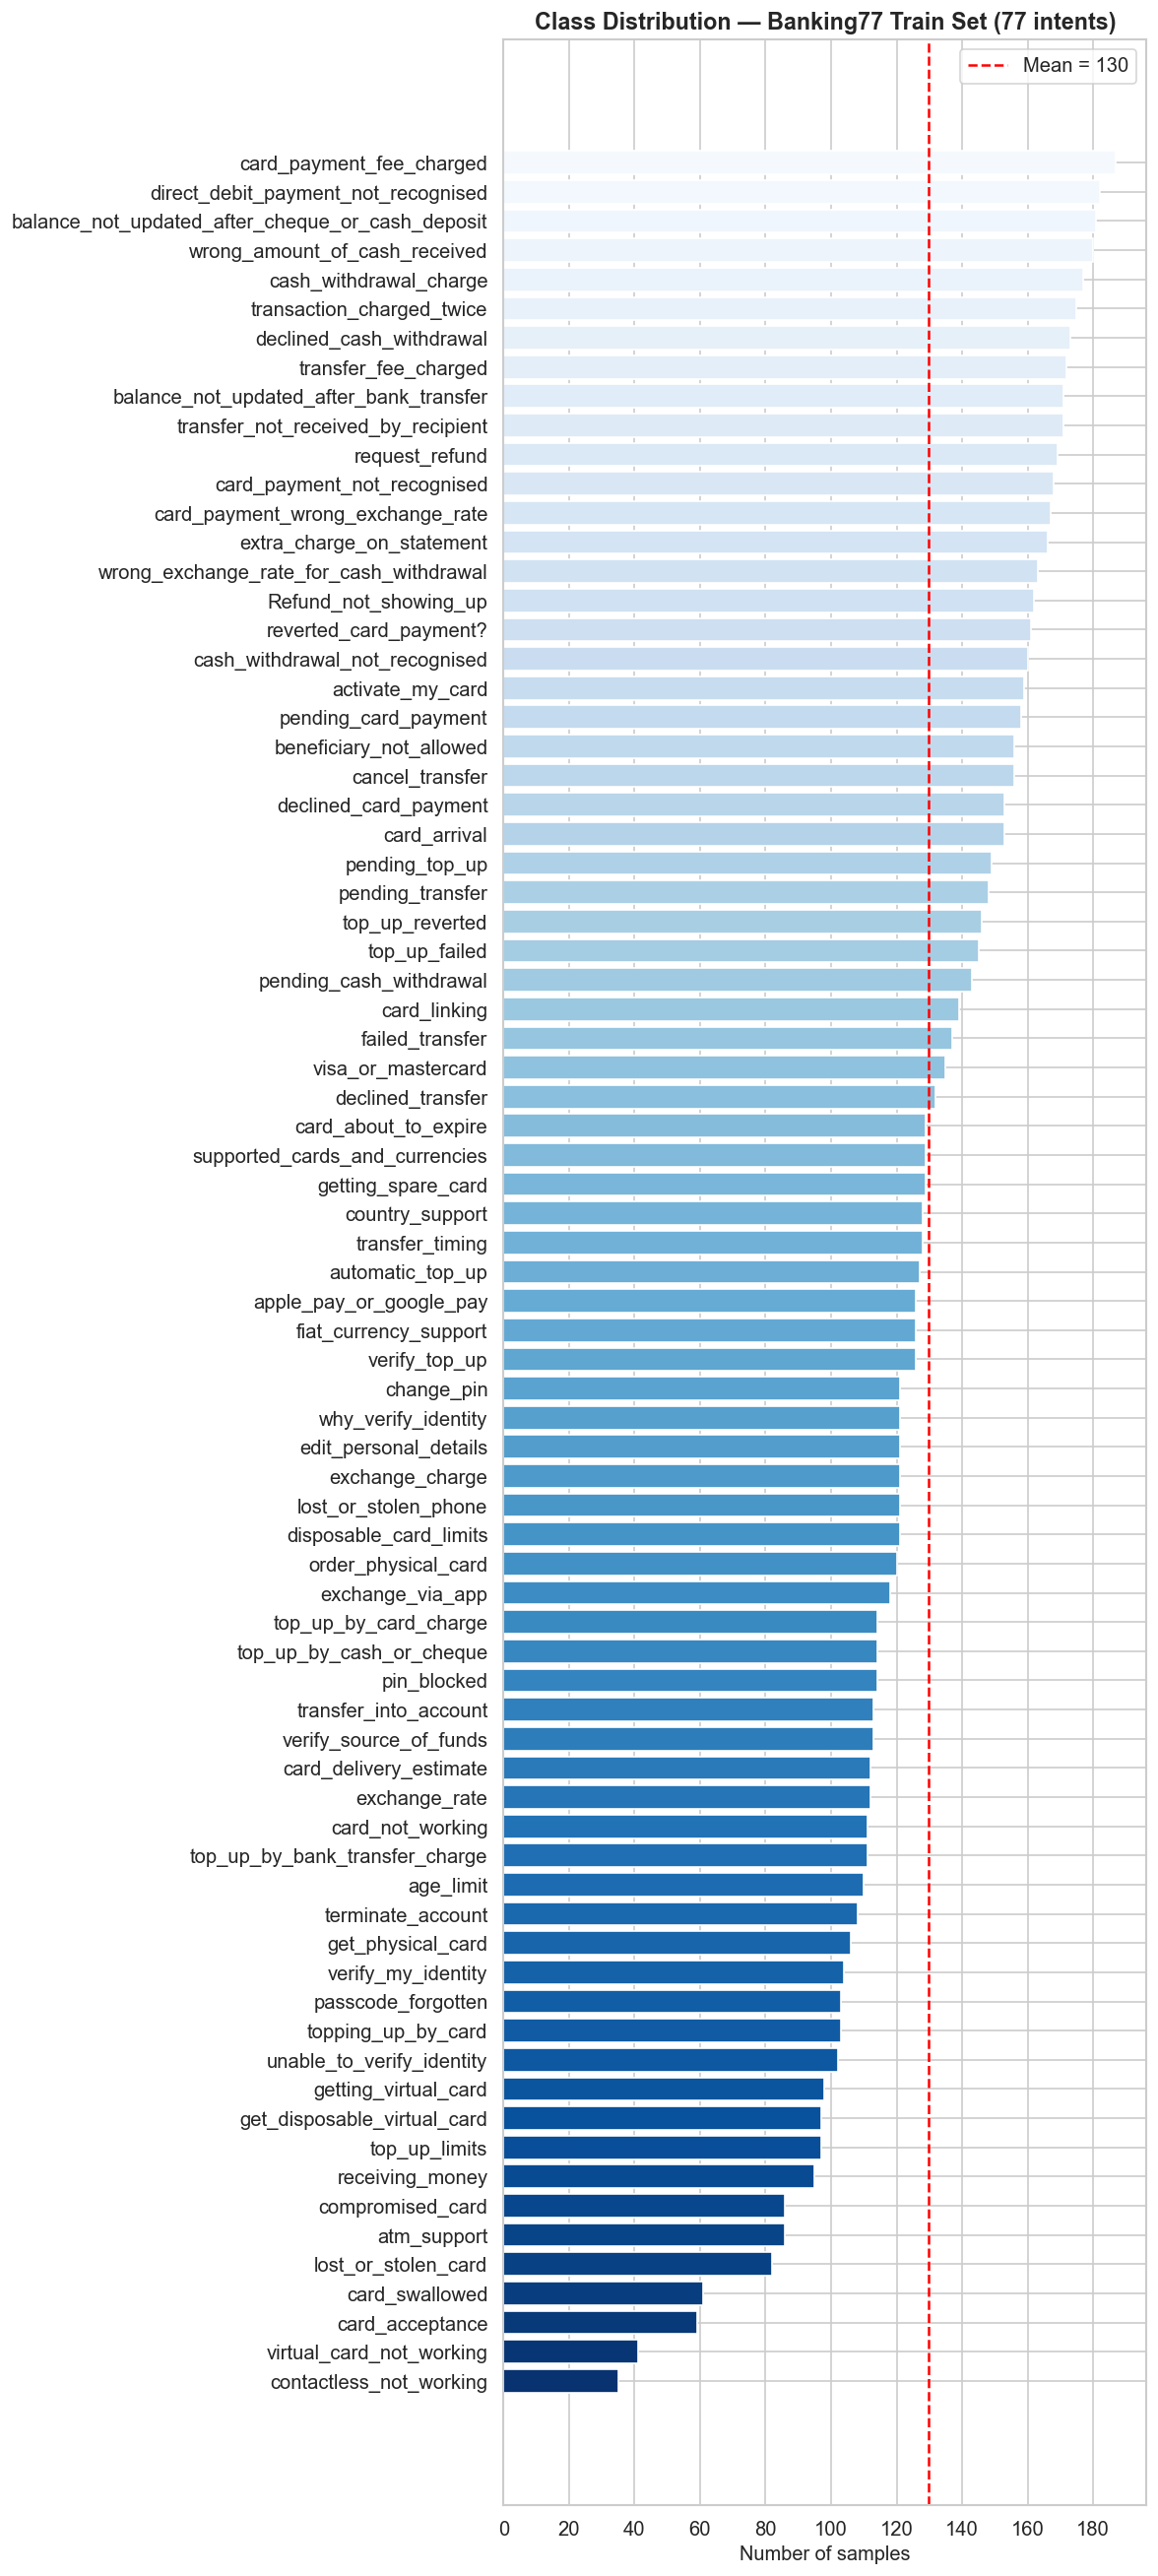

In [7]:
# ── Per-class sample counts ──────────────────────────────────────────────────
class_counts = train_df['label_text'].value_counts().sort_values()

print(f'Min samples per class : {class_counts.min()}')
print(f'Max samples per class : {class_counts.max()}')
print(f'Mean samples per class: {class_counts.mean():.1f}')
print(f'Std  samples per class: {class_counts.std():.1f}')
print()

# ── Horizontal bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 22))
bars = ax.barh(class_counts.index, class_counts.values, color=sns.color_palette('Blues_r', len(class_counts)))
ax.set_xlabel('Number of samples', fontsize=12)
ax.set_title('Class Distribution — Banking77 Train Set (77 intents)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.axvline(class_counts.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {class_counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/class_distribution.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Imbalance ratio ──────────────────────────────────────────────────────────
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}x')

# Bottom-5 and top-5 classes
print('\n--- Bottom 5 (fewest samples) ---')
print(class_counts.head(5).to_string())
print('\n--- Top 5 (most samples) ---')
print(class_counts.tail(5).to_string())

Imbalance ratio (max/min): 5.34x

--- Bottom 5 (fewest samples) ---
label_text
contactless_not_working     35
virtual_card_not_working    41
card_acceptance             59
card_swallowed              61
lost_or_stolen_card         82

--- Top 5 (most samples) ---
label_text
cash_withdrawal_charge                              177
wrong_amount_of_cash_received                       180
balance_not_updated_after_cheque_or_cash_deposit    181
direct_debit_payment_not_recognised                 182
card_payment_fee_charged                            187


## 6. Text Length Analysis

In [9]:
# Word-level lengths
train_df['word_count'] = train_df['text'].str.split().str.len()
test_df['word_count']  = test_df['text'].str.split().str.len()

# Char-level lengths
train_df['char_count'] = train_df['text'].str.len()

print('=== WORD COUNT STATS (Train) ===')
print(train_df['word_count'].describe().round(2))
print()
print('=== CHAR COUNT STATS (Train) ===')
print(train_df['char_count'].describe().round(2))

=== WORD COUNT STATS (Train) ===
count    9993.00
mean       11.96
std         7.89
min         3.00
25%         7.00
50%        10.00
75%        13.00
max        79.00
Name: word_count, dtype: float64

=== CHAR COUNT STATS (Train) ===
count    9993.00
mean       59.50
std        40.87
min        13.00
25%        36.00
50%        47.00
75%        64.00
max       433.00
Name: char_count, dtype: float64


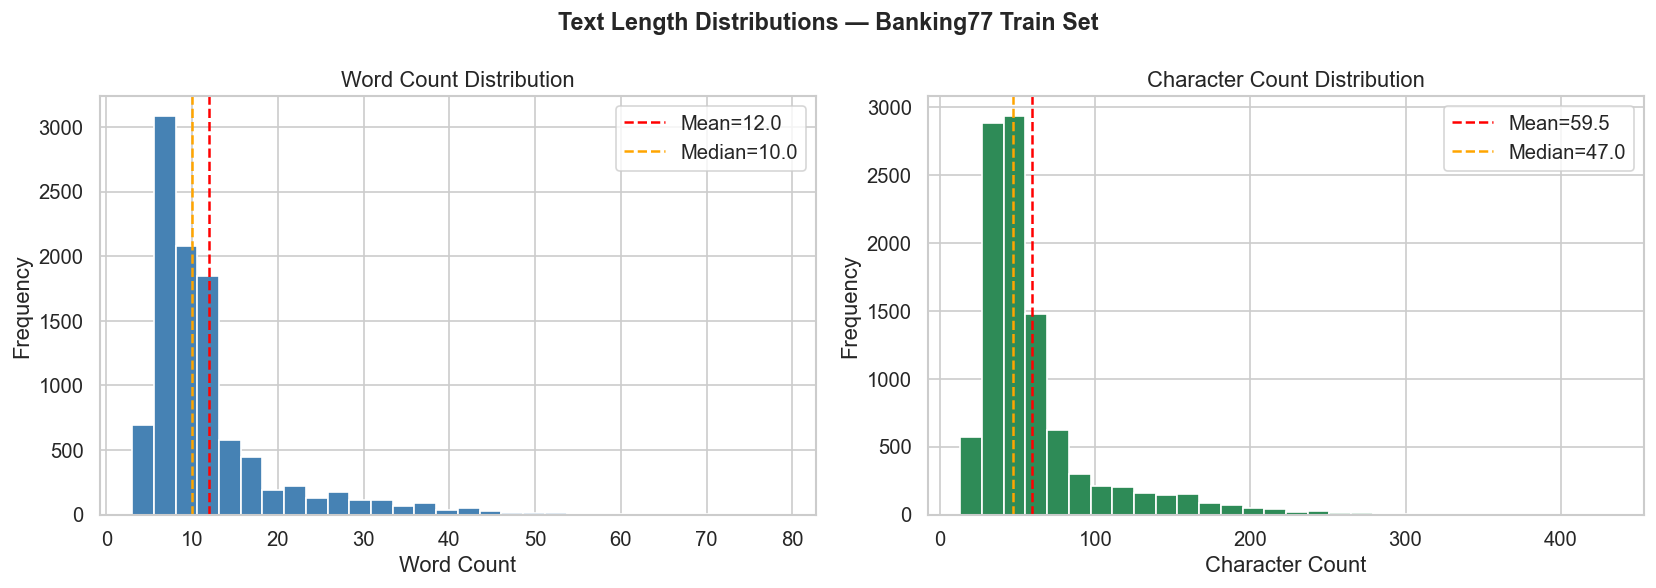

Max words in a single sample: 79
Samples exceeding 64 words  : 8
Samples exceeding 128 tokens: ~very few (safe to use max_length=128)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count histogram
axes[0].hist(train_df['word_count'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(train_df['word_count'].mean(),  color='red',    linestyle='--', label=f"Mean={train_df['word_count'].mean():.1f}")
axes[0].axvline(train_df['word_count'].median(),color='orange', linestyle='--', label=f"Median={train_df['word_count'].median():.1f}")
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution')
axes[0].legend()

# Char count histogram
axes[1].hist(train_df['char_count'], bins=30, color='seagreen', edgecolor='white')
axes[1].axvline(train_df['char_count'].mean(),  color='red',    linestyle='--', label=f"Mean={train_df['char_count'].mean():.1f}")
axes[1].axvline(train_df['char_count'].median(),color='orange', linestyle='--', label=f"Median={train_df['char_count'].median():.1f}")
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Character Count Distribution')
axes[1].legend()

fig.suptitle('Text Length Distributions — Banking77 Train Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/text_length_dist.png', bbox_inches='tight')
plt.show()

print(f'Max words in a single sample: {train_df["word_count"].max()}')
print(f'Samples exceeding 64 words  : {(train_df["word_count"] > 64).sum()}')
print(f'Samples exceeding 128 tokens: ~very few (safe to use max_length=128)')

## 7. Longest & Shortest Samples

In [11]:
print('=== LONGEST SAMPLE ===')
idx_max = train_df['word_count'].idxmax()
print(f"Words: {train_df.loc[idx_max, 'word_count']}")
print(f"Intent: {train_df.loc[idx_max, 'label_text']}")
print(f"Text: {train_df.loc[idx_max, 'text']}")
print()
print('=== SHORTEST SAMPLE ===')
idx_min = train_df['word_count'].idxmin()
print(f"Words: {train_df.loc[idx_min, 'word_count']}")
print(f"Intent: {train_df.loc[idx_min, 'label_text']}")
print(f"Text: {train_df.loc[idx_min, 'text']}")

=== LONGEST SAMPLE ===
Words: 79
Intent: unable_to_verify_identity
Text: Hearing back from us regarding your important verification results may take 10 minutes to one hour time.  If verification results do fail, double-check to make sure all of your images are clear --  make sure your photos have no glare or blurring. Note: These photos need to be readable as well.  You also need to be 18 years of age or older.  You must be a resident of Switzerland or the European Economic Area to open a new account.

=== SHORTEST SAMPLE ===
Words: 3
Intent: pending_cash_withdrawal
Text: withdrawal pending meaning?


## 8. Key Insights Summary

| Metric | Value |
|---|---|
| Train samples | 9,993 |
| Test samples | 3,076 |
| Number of intent classes | 77 |
| Missing values | 0 (both splits) |
| Min samples per class (train) | ~35 |
| Max samples per class (train) | ~187 |
| Avg word count | ~12 words |
| Max word count | ~79 words |
| Safe max_length for DistilBERT | **128 tokens** |

### Implications for Modelling

1. **Class imbalance** — The imbalance ratio (~5x) is moderate but meaningful. We must use **Macro F1** as the evaluation metric to treat all 77 classes equally.
2. **Short texts** — Average query is only ~12 words. DistilBERT with `max_length=128` is more than sufficient; no truncation will occur in practice.
3. **Clean data** — Zero nulls in both splits. No text cleaning or imputation needed before tokenisation.
4. **All 77 intents** present in both train and test → standard train/test evaluation is valid.